# 03 · Time trends and customer concentration

Actual Superstore sample data, not simulated outputs. Run cells from top to bottom. Dollar amounts are USD.


In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/project.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the extracted project folder.')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.project import load, summarize, save_table, chart
pd.set_option('display.max_columns',30)
pd.set_option('display.width',160)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize':(10,5),'axes.spines.top':False,'axes.spines.right':False})

          Sales    Profit  Sales_YoY_pct
Year                                    
2014  484247.50  49543.97            NaN
2015  470532.51  61618.60          -2.83
2016  609205.60  81795.17          29.47
2017  733215.26  93439.27          20.36


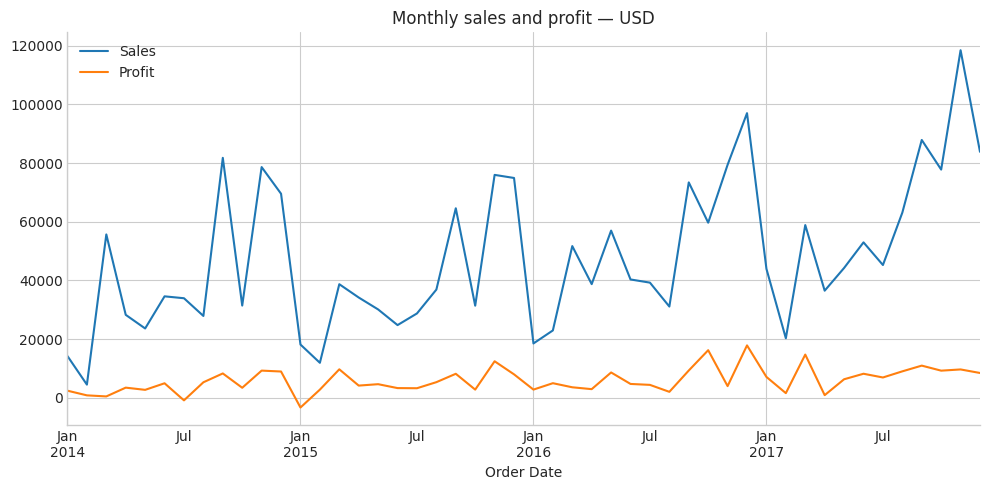

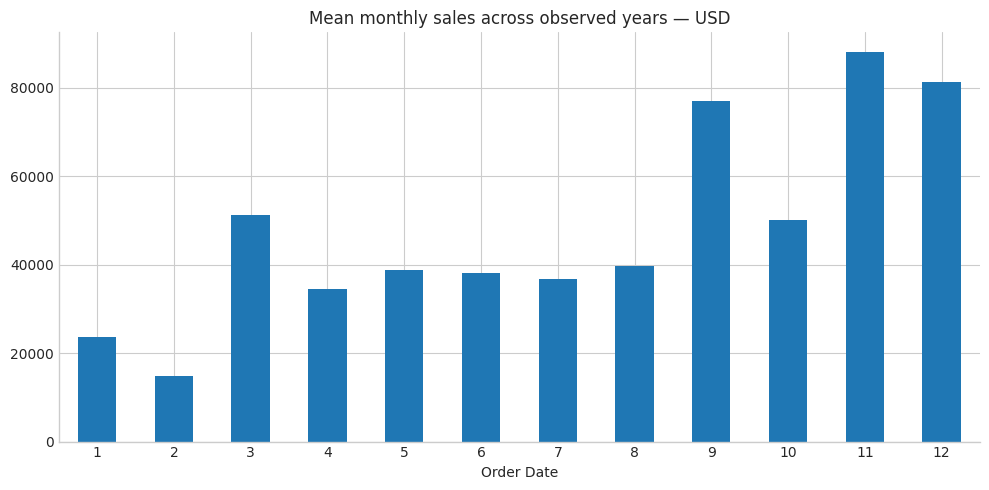

In [2]:
df=load()
monthly=df.set_index('Order Date').resample('MS')[['Sales','Profit']].sum()
monthly['Sales_YoY_pct']=monthly.Sales.pct_change(12,fill_method=None)*100
annual=df.groupby('Year')[['Sales','Profit']].sum()
annual['Sales_YoY_pct']=annual.Sales.pct_change(fill_method=None)*100
print(annual.round(2));save_table(monthly,'monthly');save_table(annual,'annual')
monthly[['Sales','Profit']].plot(title='Monthly sales and profit — USD');chart('monthly_trend')
# Total monthly sales averaged across observed years; do not use mean line sales as seasonality.
season=monthly.groupby(monthly.index.month).Sales.mean()
season.plot.bar(title='Mean monthly sales across observed years — USD',rot=0);chart('seasonality')

## Interpret time carefully
YoY compares the same calendar period. First-year YoY is undefined, not zero. Compare complete years only. A short historical sample can suggest seasonal patterns but does not guarantee future demand.

Top 80 of 793 customers (ceiling of 10%) contribute 30.88% of sales.
Repeat customer share within the observed period: 98.49%
                Sales   Profit  Orders Last_Order  Cumulative_Sales_pct
Customer ID                                                            
SM-20320     25043.05 -1980.74       5 2017-10-12                  1.09
TC-20980     19052.22  8981.32       5 2016-11-26                  1.92
RB-19360     15117.34  6976.10       6 2017-09-25                  2.58
TA-21385     14595.62  4703.79       4 2017-10-22                  3.21
AB-10105     14473.57  5444.81      10 2017-11-19                  3.84
KL-16645     14175.23   806.86      12 2017-11-13                  4.46
SC-20095     14142.33  5757.41       9 2017-01-15                  5.08
HL-15040     12873.30  5622.43       6 2017-11-17                  5.64
SE-20110     12209.44  2650.68      11 2017-12-21                  6.17
CC-12370     12129.07  2177.05       5 2017-11-17                  6.70


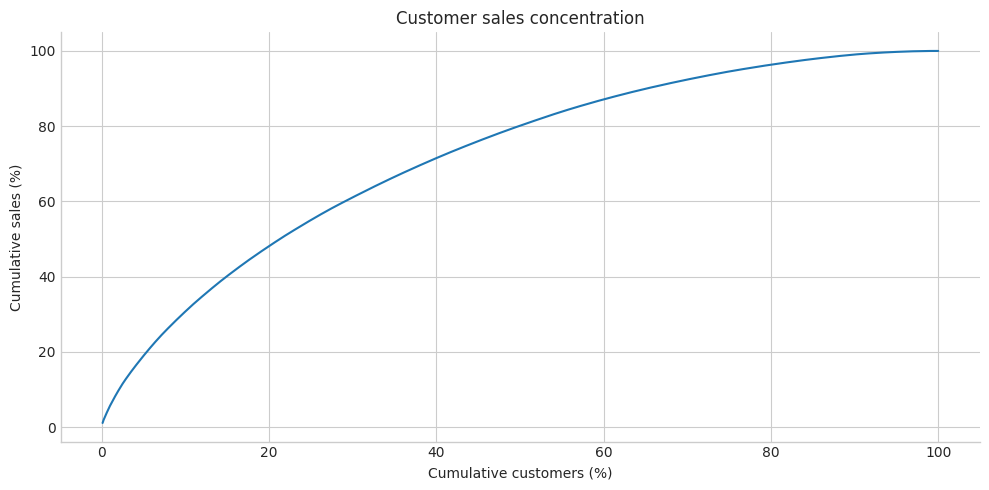

In [3]:
customers=df.groupby('Customer ID').agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Orders=('Order ID','nunique'),Last_Order=('Order Date','max'))
customers=customers.sort_values('Sales',ascending=False)
k=int(np.ceil(len(customers)*0.10))
share=100*customers.head(k).Sales.sum()/customers.Sales.sum()
repeat=100*customers.Orders.gt(1).mean()
customers['Cumulative_Sales_pct']=100*customers.Sales.cumsum()/customers.Sales.sum()
print(f'Top {k} of {len(customers)} customers (ceiling of 10%) contribute {share:.2f}% of sales.')
print(f'Repeat customer share within the observed period: {repeat:.2f}%')
print(customers.head(10).round(2));save_table(customers,'customers')
plt.plot(np.arange(1,len(customers)+1)/len(customers)*100,customers.Cumulative_Sales_pct)
plt.xlabel('Cumulative customers (%)');plt.ylabel('Cumulative sales (%)');plt.title('Customer sales concentration');chart('customer_pareto')

## RFM segmentation: descriptive, not predictive
Recency is measured one day after the last observed order, not today. Frequency counts distinct orders; monetary value sums sales. Quartile ties receive the same score where possible. These rule-based segments are priorities for investigation, not churn predictions.

In [4]:
snapshot=df['Order Date'].max()+pd.Timedelta(days=1)
customers['Recency']=(snapshot-customers.Last_Order).dt.days
for col,score,ascending in [('Recency','R',False),('Orders','F',True),('Sales','M',True)]:
    customers[score]=np.ceil(customers[col].rank(pct=True,method='average',ascending=ascending)*4).clip(1,4).astype(int)
customers['Segment_RFM']=np.select([(customers.R>=3)&(customers.F>=3)&(customers.M>=3),(customers.R<=2)&(customers.M>=3),customers.R>=3],['High-value active','High-value less recent','Recently active'],default='Other')
print(customers.groupby('Segment_RFM').agg(Customers=('Sales','size'),Sales=('Sales','sum'),Profit=('Profit','sum')).round(2))
save_table(customers,'customer_rfm')

                        Customers      Sales     Profit
Segment_RFM                                            
High-value active             168  768205.18   88153.61
High-value less recent        167  788394.31  114707.11
Other                         229  249634.62   23810.53
Recently active               229  490966.75   59725.77
